# Word2vec

In [1]:
sentences = [['this', 'is', 'a', 'first', 'example', 'of', 'text'],
    ['this', 'is', 'the', 'second', 'example'],
    ['yet', 'another', 'example'],
    ['one', 'more', 'example'],
    ['and', 'the', 'final', 'example']]

In [2]:
from gensim.models import Word2Vec

model = Word2Vec(sentences, min_count=1, vector_size=10,window=3)
print(model)


Word2Vec(vocab=15, vector_size=10, alpha=0.025)


In [3]:
words = list(model.wv.key_to_index)
print(words)



['example', 'the', 'is', 'this', 'final', 'and', 'more', 'one', 'another', 'yet', 'second', 'text', 'of', 'first', 'a']


In [4]:

print("v(final)="+str(model.wv['final']))

# save model
model.save('model.bin')

v(final)=[-0.09604949  0.05007555 -0.08759888 -0.04390896 -0.00036679 -0.00297186
 -0.07661466  0.09617318  0.04981884  0.09234031]


In [5]:
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

Word2Vec(vocab=15, vector_size=10, alpha=0.025)


In [6]:
X = model.wv[new_model.wv.key_to_index]

In [7]:
X.shape

(15, 10)

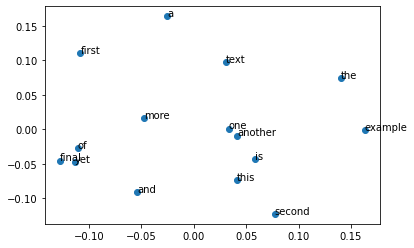

In [8]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:, 0], result[:, 1])
words = list(model.wv.key_to_index)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

In [9]:
import gensim.downloader as api

In [10]:
corpus = api.load('text8')

[==================================================] 100.0% 31.6/31.6MB downloaded


In [11]:
type(corpus)


text8.Dataset

In [12]:
from gensim.models.word2vec import Word2Vec
model8= Word2Vec(corpus)

In [13]:
model8.wv['tree']

array([ 0.9069395 , -0.9470668 ,  1.3616995 , -0.98575133,  0.35674852,
        0.65247864, -0.9969499 , -1.0792513 , -1.4124618 , -1.608358  ,
        0.59475964, -2.6817086 ,  0.32966548,  1.3503214 , -1.9746344 ,
        2.184495  ,  2.5238025 , -0.17443633,  0.04835039, -0.49359262,
       -1.3875318 , -1.7712206 ,  1.3247651 , -1.2855695 , -0.84634066,
       -0.6823609 , -0.44723013, -0.566213  , -0.09092936, -2.0676305 ,
        2.8453674 , -0.56500626,  0.26687133, -0.48045886,  2.2666626 ,
        1.3756274 ,  1.1007876 ,  0.26092994, -2.7049055 ,  0.23705949,
        0.9978627 , -1.474518  , -0.96875787,  0.05065306,  0.43295547,
       -0.94190127, -0.5266482 , -0.40674832,  0.3571445 ,  0.3370235 ,
       -2.3715436 ,  1.2355425 ,  1.0164002 ,  3.3000386 , -0.2935603 ,
       -1.2167993 , -0.22294451,  0.3052899 , -0.04110859,  0.5783979 ,
       -0.778878  , -1.7300631 , -1.4451846 ,  2.632478  , -0.78606623,
       -0.12309147, -0.44597012, -2.414418  ,  0.19131392,  0.84

In [14]:
print(model8.wv.most_similar('tree'))

[('trees', 0.7054206132888794), ('leaf', 0.696731686592102), ('bark', 0.667205274105072), ('flower', 0.6158172488212585), ('cactus', 0.6045128703117371), ('fruit', 0.5987103581428528), ('leaves', 0.5898560285568237), ('avl', 0.5810938477516174), ('bird', 0.5806726217269897), ('calf', 0.5748968124389648)]


In [15]:
print(model8.wv.doesnt_match("breakfast cereal dinner lunch".split()))

cereal


# Analogies

In [16]:
#v(king)-v(man)+v(woman)
print(model8.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3))

[('queen', 0.6723027229309082), ('empress', 0.6206991076469421), ('princess', 0.615125298500061)]


In [17]:
print(model8.wv.most_similar(positive=['italy', 'renault'], negative=['france'], topn=3))


[('mercedes', 0.7202863693237305), ('chevrolet', 0.7084687948226929), ('benz', 0.7061725854873657)]


In [25]:
print(model8.wv.most_similar(positive=['france', 'paris'], negative=['italy'], topn=3))


[('le', 0.6343140602111816), ('des', 0.6002169251441956), ('boulogne', 0.5819602012634277)]


In [38]:
print(model8.wv.most_similar(positive=['usa', 'beatles'], negative=['england'], topn=3))

[('dj', 0.6599704027175903), ('jam', 0.6126100420951843), ('unplugged', 0.5896793603897095)]


In [20]:
model8.wv.most_similar(['apple','orange'])

[('mcintosh', 0.6831961274147034),
 ('logo', 0.6323046088218689),
 ('iic', 0.6219288110733032),
 ('coleco', 0.6176586151123047),
 ('jaguar', 0.598556399345398),
 ('macintosh', 0.591188907623291),
 ('iie', 0.5886055827140808),
 ('toy', 0.5844024419784546),
 ('retailer', 0.5790247917175293),
 ('iigs', 0.5756075978279114)]

##  Loading pre-trained models

In [40]:
#Load pretrained model GoogleNews-vectors-negative300.bin.gz
#https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing

from gensim.models import KeyedVectors
model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)

FileNotFoundError: [Errno 2] No such file or directory: 'GoogleNews-vectors-negative300.bin'

In [ ]:
print(model.most_similar('tree'))

In [ ]:
print(model.most_similar(positive=['germany', 'monarchy'], negative=['netherlands'], topn=3))


In [ ]:
print(model.most_similar(positive=['italy', 'beatles'], negative=['england'], topn=3))


## Glove

In [41]:
from gensim.scripts.glove2word2vec import glove2word2vec
glove_input_file = 'glove.42B.300d.txt'
word2vec_output_file = 'glove.42B.300d.txt.word2vec'
glove2word2vec(glove_input_file, word2vec_output_file)

<ipython-input-41-eb6a065b5862>:4: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


FileNotFoundError: [Errno 2] No such file or directory: 'glove.42B.300d.txt'

In [42]:
from gensim.models import KeyedVectors

filename = 'glove.42B.300d.txt.word2vec'
model = KeyedVectors.load_word2vec_format(filename, binary=False)

result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(result)

FileNotFoundError: [Errno 2] No such file or directory: 'glove.42B.300d.txt.word2vec'

In [ ]:
print(model.most_similar('tree'))